# 07: Weighted Least Squares with Multiple Datasets

## Learning objectives
- Write down the weighted least squares (WLS) solution and parameter covariance using a data covariance matrix.
- Combine two datasets correctly when noise is similar and uncorrelated.
- Weight datasets correctly when noise levels differ, or when noise is correlated *within* a dataset.
- Recognize the challenge posed by vastly different dataset sizes and choose an appropriate strategy.
- Generalize the framework to an arbitrary number of datasets using block-diagonal covariance.

## Background: Weighted Least Squares

### The forward problem

We assume a **linear forward model**:

$$\mathbf{d} = \mathbf{G}\,\mathbf{m} + \boldsymbol{\epsilon}$$

where $\mathbf{d}$ is the $N\times 1$ data vector, $\mathbf{G}$ is the $N\times p$ design matrix, $\mathbf{m}$ is the $p\times 1$ parameter vector, and $\boldsymbol{\epsilon}$ is data noise.

### Noise model

We assume Gaussian noise with covariance $\mathbf{C}_d$:

$$\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0},\; \mathbf{C}_d)$$

For uncorrelated noise with equal variance $\sigma^2$, this is simply $\mathbf{C}_d = \sigma^2 \mathbf{I}$.  For uncorrelated noise with *different* variances, $\mathbf{C}_d = \mathrm{diag}(\sigma_1^2, \sigma_2^2, \ldots)$.  For **correlated** noise, $\mathbf{C}_d$ has off-diagonal entries.

### Weighted least squares solution

Minimizing the weighted misfit $\phi = (\mathbf{d} - \mathbf{G}\mathbf{m})^\top \mathbf{C}_d^{-1} (\mathbf{d} - \mathbf{G}\mathbf{m})$ gives:

$$\boxed{\hat{\mathbf{m}} = \left(\mathbf{G}^\top \mathbf{C}_d^{-1} \mathbf{G}\right)^{-1} \mathbf{G}^\top \mathbf{C}_d^{-1} \mathbf{d}}$$

The **parameter covariance** (uncertainty in our estimate) is:

$$\mathbf{C}_m = \left(\mathbf{G}^\top \mathbf{C}_d^{-1} \mathbf{G}\right)^{-1}$$

### Combining datasets

When we have $K$ datasets $\{\mathbf{d}_k, \mathbf{G}_k, \mathbf{C}_{d,k}\}$, we **stack** them into one big system:

$$\begin{pmatrix}\mathbf{d}_1 \\ \mathbf{d}_2 \\ \vdots \\ \mathbf{d}_K\end{pmatrix} = \begin{pmatrix}\mathbf{G}_1 \\ \mathbf{G}_2 \\ \vdots \\ \mathbf{G}_K\end{pmatrix} \mathbf{m} + \boldsymbol{\epsilon}, \qquad \mathbf{C}_d = \begin{pmatrix}\mathbf{C}_{d,1} & & \\ & \ddots & \\ & & \mathbf{C}_{d,K}\end{pmatrix}$$

The block-diagonal structure of $\mathbf{C}_d$ reflects the assumption that noise is **uncorrelated across datasets** (even if it is correlated within each one).  The WLS formula is unchanged — we just use the full stacked system.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True

rng = np.random.default_rng(7)

# ── Core WLS utility ──────────────────────────────────────────────────────────
def wls(G, d, Cd_inv):
    """Weighted least squares: m = (G^T Cd^{-1} G)^{-1} G^T Cd^{-1} d.
    Returns (m_hat, Cm) where Cm = (G^T Cd^{-1} G)^{-1}."""
    GtW = G.T @ Cd_inv
    Cm  = np.linalg.inv(GtW @ G)
    return Cm @ GtW @ d, Cm

def prediction_band(G_plt, m_hat, Cm, n_sigma=2):
    """Return (y_fit, half_width) for a ±n_sigma band from parameter covariance.
    For each x location, the prediction variance is g^T Cm g, where g is the
    corresponding row of G_plt.  We compute all of these at once by forming the
    full matrix product G_plt @ Cm @ G_plt.T and extracting the diagonal."""
    var_y = np.diag(G_plt @ Cm @ G_plt.T)
    return G_plt @ m_hat, n_sigma * np.sqrt(var_y)

def make_G(x):
    """Design matrix for y = m[0]*x + m[1]  (slope, intercept)."""
    return np.column_stack([x, np.ones(len(x))])

In [13]:
# ── True model (used throughout) ─────────────────────────────────────────────
m_true = np.array([1.5, 0.5])   # slope = 1.5,  intercept = 0.5
x_plot = np.linspace(-0.3, 6.0, 300)
G_plot = make_G(x_plot)

print(f'True model:  y = {m_true[0]} · x + {m_true[1]}')

True model:  y = 1.5 · x + 0.5


---
## Part A: Similar datasets — similar, uncorrelated noise

The simplest case: two experiments that measure the same quantity, with the same noise level $\sigma$, and no correlation within or between datasets.

Because both datasets have the same per-point noise, the combined data covariance is:

$$\mathbf{C}_d = \sigma^2 \begin{pmatrix}\mathbf{I}_{N_1} & \\ & \mathbf{I}_{N_2}\end{pmatrix} = \sigma^2 \mathbf{I}_{N_1+N_2}$$

The $\sigma^2$ factor cancels in the WLS formula — so **combining similar datasets is equivalent to just stacking the data, with no special weighting needed**.  The payoff is purely in uncertainty: $\mathbf{C}_m \propto (\mathbf{G}^\top \mathbf{G})^{-1}$, and more data makes this smaller.

Source                     slope       ±   intercept       ±
------------------------------------------------------------
True                      1.5000     ---      0.5000     ---
Dataset 1                 1.4976  0.0595      0.4454  0.1763
Dataset 2                 1.3850  0.0595      0.6585  0.1763
Combined                  1.4413  0.0420      0.5519  0.1247


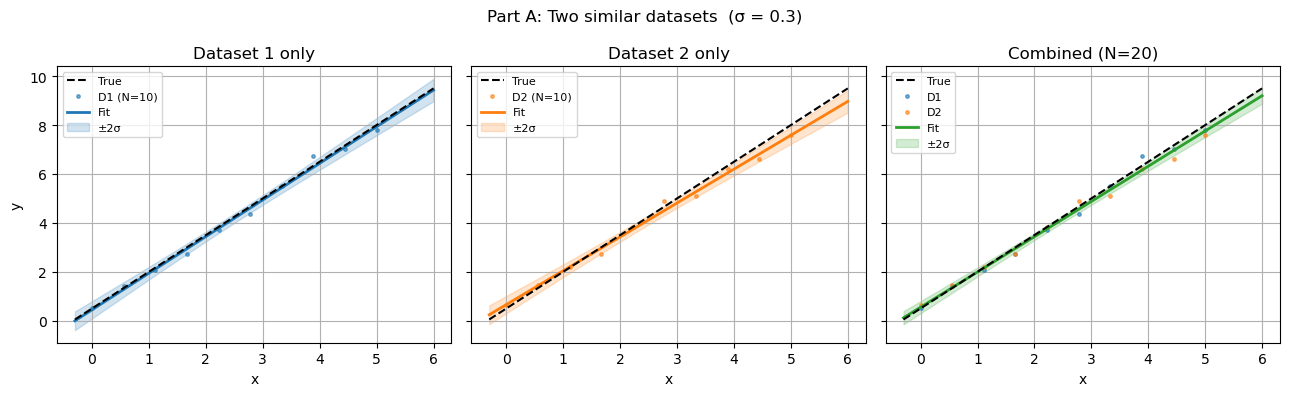

In [14]:
# ── Part A: two similar datasets ─────────────────────────────────────────────
sigma_A = 0.3
N_A     = 10
x_A1 = np.linspace(0, 5, N_A)
x_A2 = np.linspace(0, 5, N_A)   # same x-range: truly redundant measurements

G_A1, G_A2 = make_G(x_A1), make_G(x_A2)
d_A1 = G_A1 @ m_true + rng.normal(0, sigma_A, N_A)
d_A2 = G_A2 @ m_true + rng.normal(0, sigma_A, N_A)

W_A = np.eye(N_A) / sigma_A**2   # C_k^{-1} = (1/sigma^2) I

m_A1, Cm_A1 = wls(G_A1, d_A1, W_A)
m_A2, Cm_A2 = wls(G_A2, d_A2, W_A)

# Combined: stack G, d, and use block-diagonal W
G_A = np.vstack([G_A1, G_A2])
d_A = np.concatenate([d_A1, d_A2])
m_Acomb, Cm_Acomb = wls(G_A, d_A, block_diag(W_A, W_A))

# Results table
header = f"{'Source':20s}  {'slope':>10s}  {'±':>6s}  {'intercept':>10s}  {'±':>6s}"
print(header)
print('-' * len(header))
print(f"{'True':20s}  {m_true[0]:10.4f}  {'---':>6s}  {m_true[1]:10.4f}  {'---':>6s}")
print(f"{'Dataset 1':20s}  {m_A1[0]:10.4f}  {np.sqrt(Cm_A1[0,0]):6.4f}  {m_A1[1]:10.4f}  {np.sqrt(Cm_A1[1,1]):6.4f}")
print(f"{'Dataset 2':20s}  {m_A2[0]:10.4f}  {np.sqrt(Cm_A2[0,0]):6.4f}  {m_A2[1]:10.4f}  {np.sqrt(Cm_A2[1,1]):6.4f}")
print(f"{'Combined':20s}  {m_Acomb[0]:10.4f}  {np.sqrt(Cm_Acomb[0,0]):6.4f}  {m_Acomb[1]:10.4f}  {np.sqrt(Cm_Acomb[1,1]):6.4f}")

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

# Dataset 1 only
y_fit_A1, y_band_A1 = prediction_band(G_plot, m_A1, Cm_A1)
axes[0].plot(x_plot, G_plot @ m_true, 'k--', lw=1.5, label='True', zorder=5)
axes[0].plot(x_A1, d_A1, '.', color='C0', ms=5, alpha=0.6, label=f'D1 (N={N_A})')
axes[0].plot(x_plot, y_fit_A1, '-', color='C0', lw=2, label='Fit')
axes[0].fill_between(x_plot, y_fit_A1 - y_band_A1, y_fit_A1 + y_band_A1, color='C0', alpha=0.20, label='±2σ')
axes[0].set_title('Dataset 1 only')
axes[0].set_xlabel('x')
axes[0].legend(fontsize=8)

# Dataset 2 only
y_fit_A2, y_band_A2 = prediction_band(G_plot, m_A2, Cm_A2)
axes[1].plot(x_plot, G_plot @ m_true, 'k--', lw=1.5, label='True', zorder=5)
axes[1].plot(x_A2, d_A2, '.', color='C1', ms=5, alpha=0.6, label=f'D2 (N={N_A})')
axes[1].plot(x_plot, y_fit_A2, '-', color='C1', lw=2, label='Fit')
axes[1].fill_between(x_plot, y_fit_A2 - y_band_A2, y_fit_A2 + y_band_A2, color='C1', alpha=0.20, label='±2σ')
axes[1].set_title('Dataset 2 only')
axes[1].set_xlabel('x')
axes[1].legend(fontsize=8)

# Combined
y_fit_Acomb, y_band_Acomb = prediction_band(G_plot, m_Acomb, Cm_Acomb)
axes[2].plot(x_plot, G_plot @ m_true, 'k--', lw=1.5, label='True', zorder=5)
axes[2].plot(x_A1, d_A1, '.', color='C0', ms=5, alpha=0.6, label='D1')
axes[2].plot(x_A2, d_A2, '.', color='C1', ms=5, alpha=0.6, label='D2')
axes[2].plot(x_plot, y_fit_Acomb, '-', color='C2', lw=2, label='Fit')
axes[2].fill_between(x_plot, y_fit_Acomb - y_band_Acomb, y_fit_Acomb + y_band_Acomb, color='C2', alpha=0.20, label='±2σ')
axes[2].set_title(f'Combined (N={2*N_A})')
axes[2].set_xlabel('x')
axes[2].legend(fontsize=8)

axes[0].set_ylabel('y')
fig.suptitle(f'Part A: Two similar datasets  (σ = {sigma_A})', fontsize=12)
plt.tight_layout()
plt.show()

### Part A take-away

- When datasets have the **same noise level** and **no cross-dataset correlation**, combining them is trivial: stack $\mathbf{G}$ and $\mathbf{d}$, use $\mathbf{C}_d = \sigma^2 \mathbf{I}$.
- The **point estimate** does not change much (both datasets already see the same model), but **uncertainty shrinks** — roughly by $1/\sqrt{2}$ in standard deviation for a second identical dataset.
- The $\sigma^2$ scalar cancels in the WLS formula, so you do not even need to know $\sigma$ to get the right $\hat{\mathbf{m}}$ (though you do need it for $\mathbf{C}_m$).

---
## Part B: Different noise levels and correlated noise

### Part B1 — Uncorrelated noise, different amplitudes

Suppose dataset 1 is precise ($\sigma_1 = 0.1$) and dataset 2 is noisy ($\sigma_2 = 1.0$).  The correct data covariance is:

$$\mathbf{C}_d = \begin{pmatrix}\sigma_1^2 \mathbf{I}_{N} & \\ & \sigma_2^2 \mathbf{I}_{N}\end{pmatrix}, \qquad
\mathbf{C}_d^{-1} = \begin{pmatrix}\frac{1}{\sigma_1^2} \mathbf{I}_{N} & \\ & \frac{1}{\sigma_2^2} \mathbf{I}_{N}\end{pmatrix}$$

Each data point is weighted by $1/\sigma_k^2$ — precise data points contribute $\left(\sigma_2/\sigma_1\right)^2 = 100\times$ more than noisy ones.

If we **ignore the difference** and use equal weights ($\mathbf{W} = \mathbf{I}$), the noisy dataset gets as much say as the precise one, pulling the solution away from the truth.

Source                             slope       ±   intercept       ±
-----------------------------------------------------------------
True                              1.5000     ---      0.5000     ---
D1 alone (σ=0.1)                  1.5151  0.0198      0.4013  0.0588
D2 alone (σ=1.0)                  1.7378  0.1982     -0.4331  0.5878
Combined — proper 1/σ² wts        1.5173  0.0197      0.3931  0.0585
Combined — equal weights ✗        1.6265  0.1401     -0.0159  0.4156


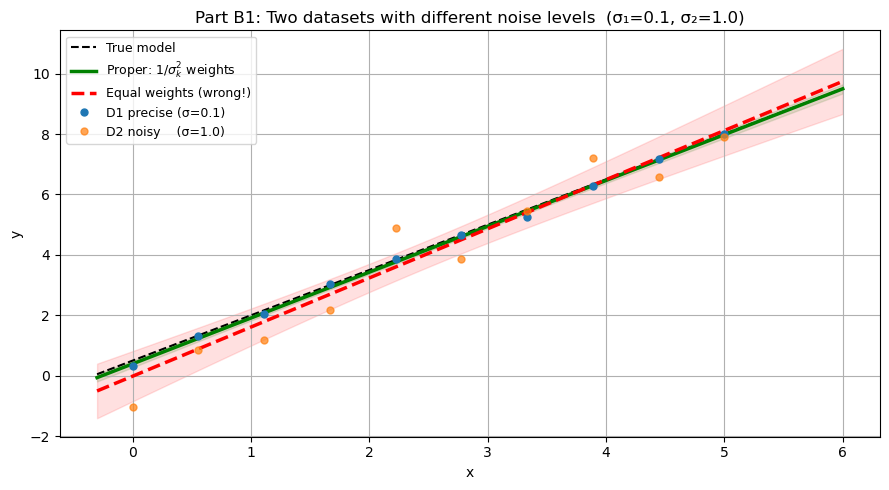

In [15]:
# ── Part B1: Different (uncorrelated) noise levels ────────────────────────────
sigma_B1, sigma_B2 = 0.1, 1.0
N_B = 10
x_B = np.linspace(0, 5, N_B)
G_B = make_G(x_B)

d_B1 = G_B @ m_true + rng.normal(0, sigma_B1, N_B)
d_B2 = G_B @ m_true + rng.normal(0, sigma_B2, N_B)

G_B_stack = np.vstack([G_B, G_B])
d_B_stack = np.concatenate([d_B1, d_B2])

# Proper weights: 1/sigma_k^2 for each dataset
W_B_proper = block_diag(np.eye(N_B)/sigma_B1**2, np.eye(N_B)/sigma_B2**2)
m_B_proper, Cm_B_proper = wls(G_B_stack, d_B_stack, W_B_proper)

# Wrong: treat both datasets as equally reliable
W_B_equal  = np.eye(2*N_B)
m_B_equal,  Cm_B_equal  = wls(G_B_stack, d_B_stack, W_B_equal)

# Each dataset solved alone (for comparison)
m_B1_solo, Cm_B1_solo = wls(G_B, d_B1, np.eye(N_B)/sigma_B1**2)
m_B2_solo, Cm_B2_solo = wls(G_B, d_B2, np.eye(N_B)/sigma_B2**2)

print(f"{'Source':30s}  {'slope':>8s}  {'±':>6s}  {'intercept':>10s}  {'±':>6s}")
print('-'*65)
print(f"{'True':30s}  {m_true[0]:8.4f}  {'---':>6s}  {m_true[1]:10.4f}  {'---':>6s}")
print(f"{f'D1 alone (σ={sigma_B1})':30s}  {m_B1_solo[0]:8.4f}  {np.sqrt(Cm_B1_solo[0,0]):6.4f}  {m_B1_solo[1]:10.4f}  {np.sqrt(Cm_B1_solo[1,1]):6.4f}")
print(f"{f'D2 alone (σ={sigma_B2})':30s}  {m_B2_solo[0]:8.4f}  {np.sqrt(Cm_B2_solo[0,0]):6.4f}  {m_B2_solo[1]:10.4f}  {np.sqrt(Cm_B2_solo[1,1]):6.4f}")
print(f"{'Combined — proper 1/σ² wts':30s}  {m_B_proper[0]:8.4f}  {np.sqrt(Cm_B_proper[0,0]):6.4f}  {m_B_proper[1]:10.4f}  {np.sqrt(Cm_B_proper[1,1]):6.4f}")
print(f"{'Combined — equal weights ✗':30s}  {m_B_equal[0]:8.4f}  {np.sqrt(Cm_B_equal[0,0]):6.4f}  {m_B_equal[1]:10.4f}  {np.sqrt(Cm_B_equal[1,1]):6.4f}")

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_plot, G_plot @ m_true, 'k--', lw=1.5, label='True model')

# Proper weights fit
y_fit_proper, y_band_proper = prediction_band(G_plot, m_B_proper, Cm_B_proper)
ax.plot(x_plot, y_fit_proper, color='green', ls='-', lw=2.5, label=r'Proper: $1/\sigma_k^2$ weights')
ax.fill_between(x_plot, y_fit_proper - y_band_proper, y_fit_proper + y_band_proper, color='green', alpha=0.12)

# Equal weights fit (wrong)
y_fit_equal, y_band_equal = prediction_band(G_plot, m_B_equal, Cm_B_equal)
ax.plot(x_plot, y_fit_equal, color='red', ls='--', lw=2.5, label='Equal weights (wrong!)')
ax.fill_between(x_plot, y_fit_equal - y_band_equal, y_fit_equal + y_band_equal, color='red', alpha=0.12)

ax.plot(x_B, d_B1, 'C0.', ms=10, label=f'D1 precise (σ={sigma_B1})')
ax.plot(x_B, d_B2, 'C1.', ms=10, alpha=0.7, label=f'D2 noisy    (σ={sigma_B2})')

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'Part B1: Two datasets with different noise levels  (σ₁={sigma_B1}, σ₂={sigma_B2})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Part B1 take-away

> **Equal weights assume equal noise.** When dataset noise levels differ, equal weighting lets the noisy dataset bias the solution.  Proper $1/\sigma_k^2$ weighting means the combined solution is nearly identical to the precise dataset alone — but with slightly smaller uncertainty because the noisy dataset still contributes *some* information.

Note that the properly-weighted combined uncertainty is **narrower** than D1 alone — even a noisy second dataset helps, as long as it is properly down-weighted.

### Part B2 — Correlated noise within a dataset

Real data often has **spatially or temporally correlated noise** (e.g., GPS displacement time series, InSAR images, or seismic waveforms).  In that case $\mathbf{C}_d$ is not diagonal — it has off-diagonal entries that encode the correlation structure.

A common model is the **squared-exponential** (Gaussian) covariance:

$$[\mathbf{C}_d]_{ij} = \sigma^2 \exp\!\left(-\frac{(x_i - x_j)^2}{2\ell^2}\right)$$

where $\ell$ is the **correlation length**.  When $\ell$ is large, neighbouring observations are nearly identical — the dataset effectively carries *fewer* independent pieces of information than $N$ suggests.

**If we naively use $\mathbf{W} = \mathbf{I}/\sigma^2$ instead of $\mathbf{C}_d^{-1}$, we underestimate uncertainty** — we act as if $N$ observations are fully independent, when in reality many of them are nearly redundant.

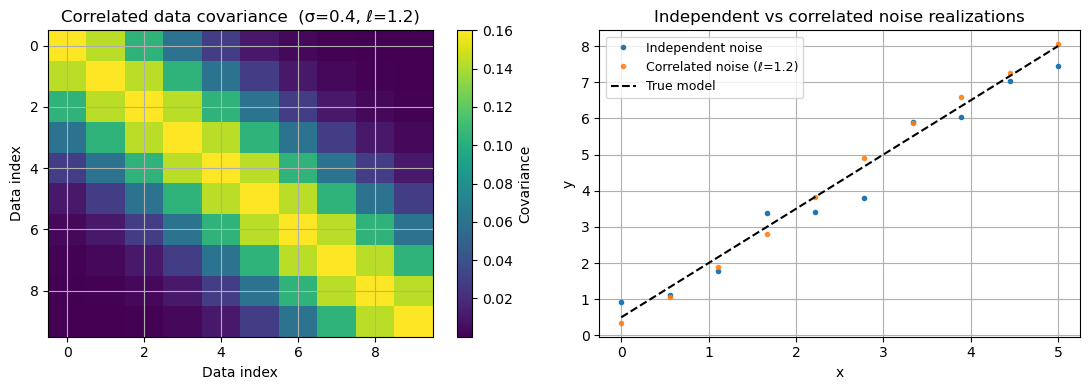

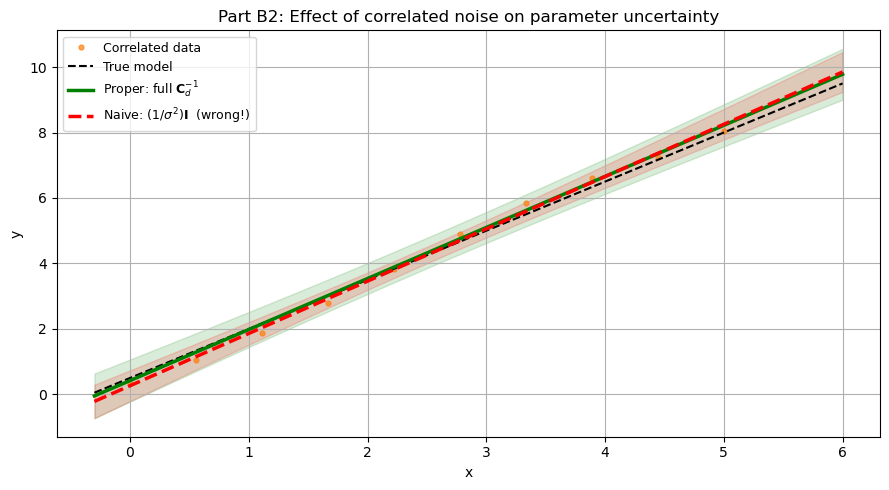

Parameter uncertainty comparison (correlated dataset):
  Proper C⁻¹:     std(slope) = 0.0892,  std(intercept) = 0.3224
  Naive (1/σ²)I:  std(slope) = 0.0793,  std(intercept) = 0.2351

Naive weighting UNDERESTIMATES uncertainty: it treats correlated data
as if they were N independent observations, inflating effective sample size.


In [20]:
# ── Part B2: Correlated noise within a dataset ────────────────────────────────
N_corr    = 10
sigma_corr = 0.4
ell        = 1.2    # correlation length in x units

x_corr = np.linspace(0, 5, N_corr)
G_corr = make_G(x_corr)

# Build full covariance matrix (squared-exponential kernel)
dx = x_corr[:, None] - x_corr[None, :]          # (N, N) distance matrix
C_corr   = sigma_corr**2 * np.exp(-0.5 * (dx/ell)**2)
C_uncorr = sigma_corr**2 * np.eye(N_corr)        # same variance, no correlation

# Add a small nugget to the diagonal for numerical stability.
# Without this, the matrix can become nearly singular when N is large or ell is
# large relative to the point spacing, causing the inversion to fail.
# Physically, the nugget represents a tiny amount of independent measurement noise
# on top of the correlated signal.
nugget = 1e-6 * sigma_corr**2
C_corr_reg = C_corr + nugget * np.eye(N_corr)

# Generate correlated noise via Cholesky decomposition: noise = L @ z,  z ~ N(0,I)
L_chol    = np.linalg.cholesky(C_corr_reg)
noise_corr   = L_chol @ rng.standard_normal(N_corr)
noise_uncorr = rng.normal(0, sigma_corr, N_corr)   # independent draw for comparison

d_corr   = G_corr @ m_true + noise_corr
d_uncorr = G_corr @ m_true + noise_uncorr

# WLS with proper full C^{-1} vs naive diagonal W
C_corr_inv   = np.linalg.inv(C_corr_reg)          # use the regularized matrix
C_uncorr_inv = np.eye(N_corr) / sigma_corr**2

m_prop,  Cm_prop  = wls(G_corr, d_corr, C_corr_inv)    # proper
m_naive, Cm_naive = wls(G_corr, d_corr, C_uncorr_inv)  # naive (wrong!)

# ── Figure 1: covariance matrix and noise realizations ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].imshow(C_corr, aspect='auto', cmap='viridis')
plt.colorbar(im, ax=axes[0], label='Covariance')
axes[0].set_title(f'Correlated data covariance  (σ={sigma_corr}, ℓ={ell})')
axes[0].set_xlabel('Data index');  axes[0].set_ylabel('Data index')

axes[1].plot(x_corr, d_uncorr, 'C0.', ms=6, label='Independent noise')
axes[1].plot(x_corr, d_corr,   'C1.', ms=6, alpha=0.85, label=f'Correlated noise (ℓ={ell})')
axes[1].plot(x_corr, G_corr @ m_true, 'k--', lw=1.5, label='True model')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].set_title('Independent vs correlated noise realizations')
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

# ── Figure 2: fits and uncertainty bands ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_corr, d_corr, 'C1.', ms=7, alpha=0.7, label='Correlated data')
ax.plot(x_plot, G_plot @ m_true, 'k--', lw=1.5, label='True model')

# Proper fit
y_fit_prop, y_band_prop = prediction_band(G_plot, m_prop, Cm_prop)
ax.plot(x_plot, y_fit_prop, color='green', ls='-', lw=2.5, label=r'Proper: full $\mathbf{C}_d^{-1}$')
ax.fill_between(x_plot, y_fit_prop - y_band_prop, y_fit_prop + y_band_prop, color='green', alpha=0.15)

# Naive fit (wrong)
y_fit_naive, y_band_naive = prediction_band(G_plot, m_naive, Cm_naive)
ax.plot(x_plot, y_fit_naive, color='red', ls='--', lw=2.5, label=r'Naive: $(1/\sigma^2)\mathbf{I}$  (wrong!)')
ax.fill_between(x_plot, y_fit_naive - y_band_naive, y_fit_naive + y_band_naive, color='red', alpha=0.15)

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Part B2: Effect of correlated noise on parameter uncertainty')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print('Parameter uncertainty comparison (correlated dataset):')
print(f'  Proper C⁻¹:     std(slope) = {np.sqrt(Cm_prop[0,0]):.4f},  std(intercept) = {np.sqrt(Cm_prop[1,1]):.4f}')
print(f'  Naive (1/σ²)I:  std(slope) = {np.sqrt(Cm_naive[0,0]):.4f},  std(intercept) = {np.sqrt(Cm_naive[1,1]):.4f}')
print()
print('Naive weighting UNDERESTIMATES uncertainty: it treats correlated data')
print('as if they were N independent observations, inflating effective sample size.')

### Part B2 take-away

> **Correlated noise inflates the apparent information content.** If you use $\mathbf{W} = (1/\sigma^2)\mathbf{I}$ when noise is spatially correlated, you are treating $N$ correlated observations as $N$ independent ones.  This leads to **over-confident parameter estimates** — the uncertainty bands are too narrow.  The correct fix is to use the full $\mathbf{C}_d^{-1}$.

Intuitively: 50 GPS stations spaced 10 km apart carry more information than 50 stations clustered within 1 km.  The covariance matrix captures that distinction automatically.

---
## Part C: Vastly different numbers of data points

Suppose you have two *types* of data — say, GPS measurements and InSAR pixels — both measuring the same model, with:

| Dataset | $N$ | $\sigma$ |
|---------|-----|----------|
| D1 (GPS) | 15  | 0.3 |
| D2 (InSAR) | 1500 | 0.3 |

Both have the same per-point noise, but D2 has 10× more observations.  **Standard per-point WLS is statistically correct here** — more data really does give more information.  But problems arise in practice:

1. **Systematic errors**: If D2 has a calibration offset, its 1500 points will dominate and bias the solution.
2. **Redundancy**: If D2 is a dense grid of highly correlated pixels, those 1500 points may carry far less independent information than their count suggests.
3. **Scientific intent**: Sometimes you want each dataset *type* to have equal influence regardless of count (e.g., you trust GPS and InSAR equally as evidence about a fault model).

A practical solution is **dataset-level normalization**: scale each dataset's covariance by $N_k / N_\text{ref}$, which gives every dataset equal total weight regardless of how many data points it contains:

$$\tilde{\mathbf{C}}_{d,k} = \frac{N_k}{N_\text{ref}} \mathbf{C}_{d,k}  \quad\Longrightarrow\quad \tilde{\mathbf{C}}_{d,k}^{-1} = \frac{N_\text{ref}}{N_k} \mathbf{C}_{d,k}^{-1}$$

This effectively divides each data point's weight by the size of its dataset.

D2 has a systematic bias of +0 applied to all points.

Source                                  slope       ±   intercept       ±
------------------------------------------------------------------------
True                                   1.5000     ---      0.5000     ---
D1 alone     (N=15)                    1.4195  0.0502      0.7802  0.1475
D2 alone     (N=1500, +bias)           2.5186  0.0358      0.4093  0.1032
Per-point weights (D2 dominates)       2.1487  0.0291      0.6027  0.0845
Dataset-normalized weights             1.4408  0.0497      0.7794  0.1460


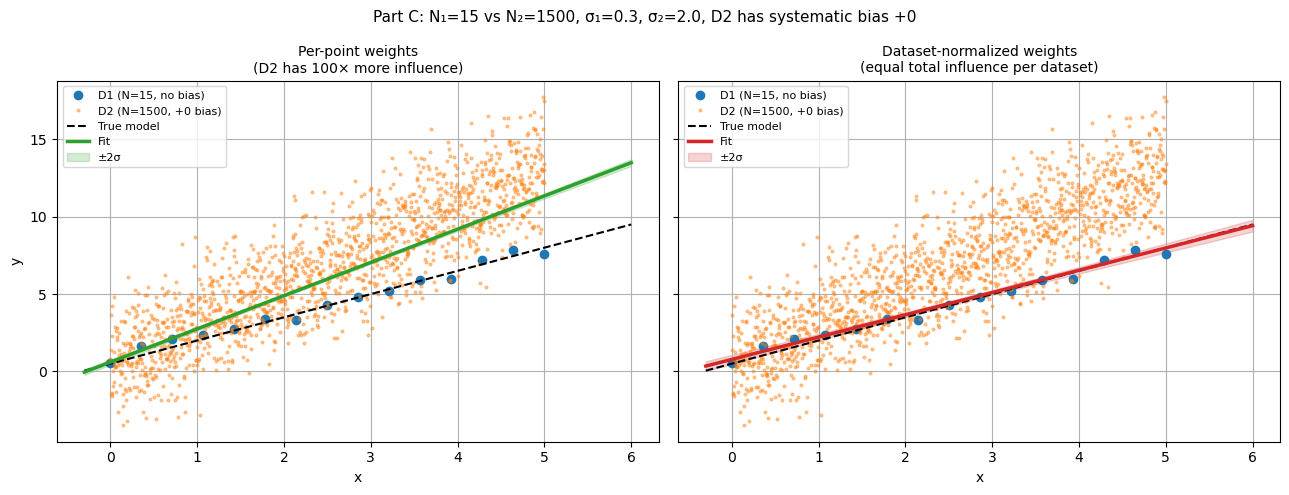

In [27]:
# ── Part C: Very different N ──────────────────────────────────────────────────
sigma_C1       = 0.3
sigma_C2       = 2.0
N_C1, N_C2   = 15, 1500
bias_C2       = 0    # systematic calibration offset in D2

x_C1 = np.linspace(0, 5, N_C1)
x_C2 = np.linspace(0, 5, N_C2)
G_C1, G_C2 = make_G(x_C1), make_G(x_C2)

d_C1 = G_C1 @ m_true + rng.normal(0, sigma_C1, N_C1)
d_C2 = G_C2 @ m_true + rng.normal(0, sigma_C2, N_C2) + bias_C2  + G_C2 @ [1,0] # biased!

G_C = np.vstack([G_C1, G_C2])
d_C = np.concatenate([d_C1, d_C2])

# Weight option 1: standard per-point weights (D2 has 10× the influence)
W_C1_pp = np.eye(N_C1) / sigma_C1**2
W_C2_pp = np.eye(N_C2) / sigma_C2**2
W_C_perpoint = block_diag(W_C1_pp, W_C2_pp)
m_C_pp, Cm_C_pp = wls(G_C, d_C, W_C_perpoint)

# Weight option 2: dataset-normalized (equal total weight per dataset)
# Scale W_k by N_ref / N_k so that sum of weights within each dataset is the same
N_ref = N_C1   # use the smaller dataset as the reference scale
W_C1_norm = W_C1_pp * (N_ref / N_C1)   # = W_C1_pp (no change, it IS the reference)
W_C2_norm = W_C2_pp * (N_ref / N_C2)   # downweight D2 by factor N_C1/N_C2
W_C_norm  = block_diag(W_C1_norm, W_C2_norm)
m_C_norm, Cm_C_norm = wls(G_C, d_C, W_C_norm)

# Each dataset alone
m_C1_solo, Cm_C1_solo = wls(G_C1, d_C1, W_C1_pp)
m_C2_solo, Cm_C2_solo = wls(G_C2, d_C2, W_C2_pp)

print(f'D2 has a systematic bias of +{bias_C2} applied to all points.')
print()
print(f"{'Source':35s}  {'slope':>8s}  {'±':>6s}  {'intercept':>10s}  {'±':>6s}")
print('-'*72)
print(f"{'True':35s}  {m_true[0]:8.4f}  {'---':>6s}  {m_true[1]:10.4f}  {'---':>6s}")
print(f"{f'D1 alone     (N={N_C1})':35s}  {m_C1_solo[0]:8.4f}  {np.sqrt(Cm_C1_solo[0,0]):6.4f}  {m_C1_solo[1]:10.4f}  {np.sqrt(Cm_C1_solo[1,1]):6.4f}")
print(f"{f'D2 alone     (N={N_C2}, +bias)':35s}  {m_C2_solo[0]:8.4f}  {np.sqrt(Cm_C2_solo[0,0]):6.4f}  {m_C2_solo[1]:10.4f}  {np.sqrt(Cm_C2_solo[1,1]):6.4f}")
print(f"{'Per-point weights (D2 dominates)':35s}  {m_C_pp[0]:8.4f}  {np.sqrt(Cm_C_pp[0,0]):6.4f}  {m_C_pp[1]:10.4f}  {np.sqrt(Cm_C_pp[1,1]):6.4f}")
print(f"{'Dataset-normalized weights':35s}  {m_C_norm[0]:8.4f}  {np.sqrt(Cm_C_norm[0,0]):6.4f}  {m_C_norm[1]:10.4f}  {np.sqrt(Cm_C_norm[1,1]):6.4f}")

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Per-point weights panel
y_fit_pp, y_band_pp = prediction_band(G_plot, m_C_pp, Cm_C_pp)
axes[0].plot(x_C1, d_C1, 'C0o', ms=6, label=f'D1 (N={N_C1}, no bias)')
axes[0].plot(x_C2, d_C2, 'C1.', ms=4, alpha=0.4, label=f'D2 (N={N_C2}, +{bias_C2} bias)')
axes[0].plot(x_plot, G_plot @ m_true, 'k--', lw=1.5, label='True model')
axes[0].plot(x_plot, y_fit_pp, '-', color='C2', lw=2.5, label='Fit')
axes[0].fill_between(x_plot, y_fit_pp - y_band_pp, y_fit_pp + y_band_pp, color='C2', alpha=0.20, label='±2σ')
axes[0].set_title(f'Per-point weights\n(D2 has {N_C2//N_C1}× more influence)', fontsize=10)
axes[0].set_xlabel('x')
axes[0].legend(fontsize=8)

# Dataset-normalized weights panel
y_fit_norm, y_band_norm = prediction_band(G_plot, m_C_norm, Cm_C_norm)
axes[1].plot(x_C1, d_C1, 'C0o', ms=6, label=f'D1 (N={N_C1}, no bias)')
axes[1].plot(x_C2, d_C2, 'C1.', ms=4, alpha=0.4, label=f'D2 (N={N_C2}, +{bias_C2} bias)')
axes[1].plot(x_plot, G_plot @ m_true, 'k--', lw=1.5, label='True model')
axes[1].plot(x_plot, y_fit_norm, '-', color='C3', lw=2.5, label='Fit')
axes[1].fill_between(x_plot, y_fit_norm - y_band_norm, y_fit_norm + y_band_norm, color='C3', alpha=0.20, label='±2σ')
axes[1].set_title('Dataset-normalized weights\n(equal total influence per dataset)', fontsize=10)
axes[1].set_xlabel('x')
axes[1].legend(fontsize=8)

axes[0].set_ylabel('y')
fig.suptitle(f'Part C: N₁={N_C1} vs N₂={N_C2}, σ₁={sigma_C1}, σ₂={sigma_C2}, D2 has systematic bias +{bias_C2}', fontsize=11)
plt.tight_layout()
plt.show()

### Part C take-away

> **More data is not always better if one dataset has a systematic error.**  Per-point weighting is statistically optimal when all data have the same quality and measure exactly the same model — but the large dataset will dominate, and any bias in it will propagate.

**When to use per-point weights**: You trust both datasets equally on a per-observation basis, and they are truly measuring the same underlying model redundantly.

**When to normalize by dataset size**: Each dataset represents a distinct measurement *type* and you want both types to have equal scientific influence, regardless of how many observations each type provides.  This is common in joint inversions (e.g., geodesy + seismology + gravity) where different data types constrain different aspects of the model.

**Another common approach**: Treat the per-dataset weight as a **hyperparameter** and estimate it from the data (e.g., via cross-validation or empirical Bayes).  This avoids having to choose the normalization by hand.

---
## Part D: Generalizing to K datasets

Everything above generalizes cleanly to $K$ datasets.  Define:

$$\mathbf{d}_\text{all} = \begin{pmatrix}\mathbf{d}_1 \\ \vdots \\ \mathbf{d}_K\end{pmatrix}, \quad
\mathbf{G}_\text{all} = \begin{pmatrix}\mathbf{G}_1 \\ \vdots \\ \mathbf{G}_K\end{pmatrix}, \quad
\mathbf{C}_d = \begin{pmatrix}\alpha_1 \mathbf{C}_{d,1} & & \\ & \ddots & \\ & & \alpha_K \mathbf{C}_{d,K}\end{pmatrix}$$

where $\alpha_k > 0$ are optional **dataset-level scaling factors** that let you up- or down-weight entire datasets (e.g., $\alpha_k = N_k / N_\text{ref}$ for size normalization, or $\alpha_k$ tuned by cross-validation).  The WLS solution is unchanged:

$$\hat{\mathbf{m}} = \left(\mathbf{G}_\text{all}^\top \mathbf{C}_d^{-1} \mathbf{G}_\text{all}\right)^{-1} \mathbf{G}_\text{all}^\top \mathbf{C}_d^{-1} \mathbf{d}_\text{all}$$

In code, `scipy.linalg.block_diag` makes it easy to assemble $\mathbf{C}_d^{-1}$ from the individual dataset weight matrices.

K = 5 datasets combined
  Dataset sizes:  [20, 40, 12, 60, 25]
  Noise levels:   [0.15, 0.5, 0.08, 0.9, 0.3]

Method                             slope       ±   intercept       ±
-------------------------------------------------------------------
True                              1.5000     ---      0.5000     ---
Per-point weights                 1.4895  0.0118      0.5197  0.0400
Dataset-normalized wts            1.4905  0.0143      0.5238  0.0514


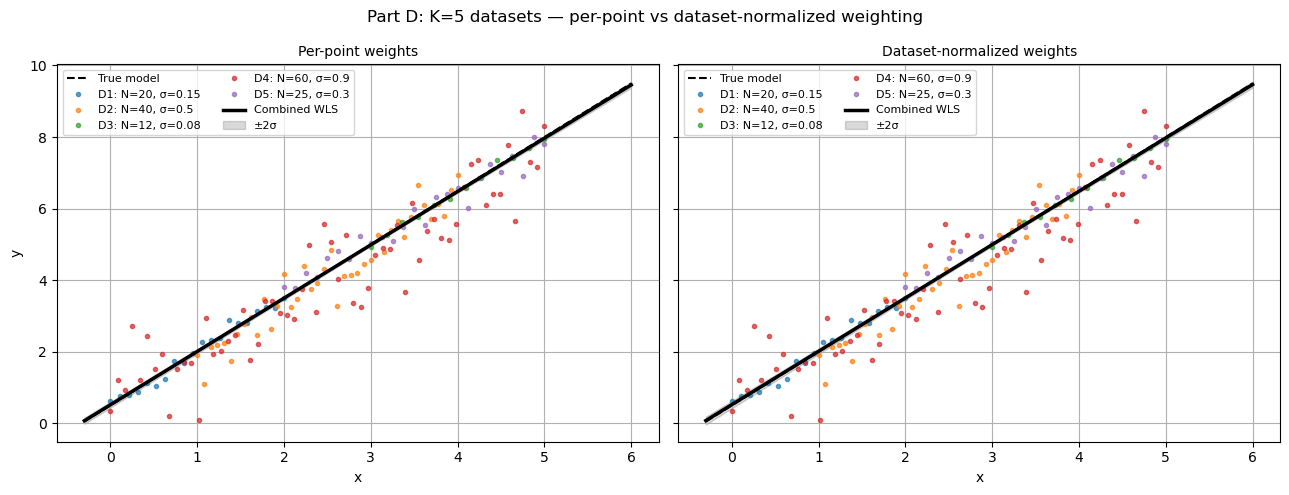

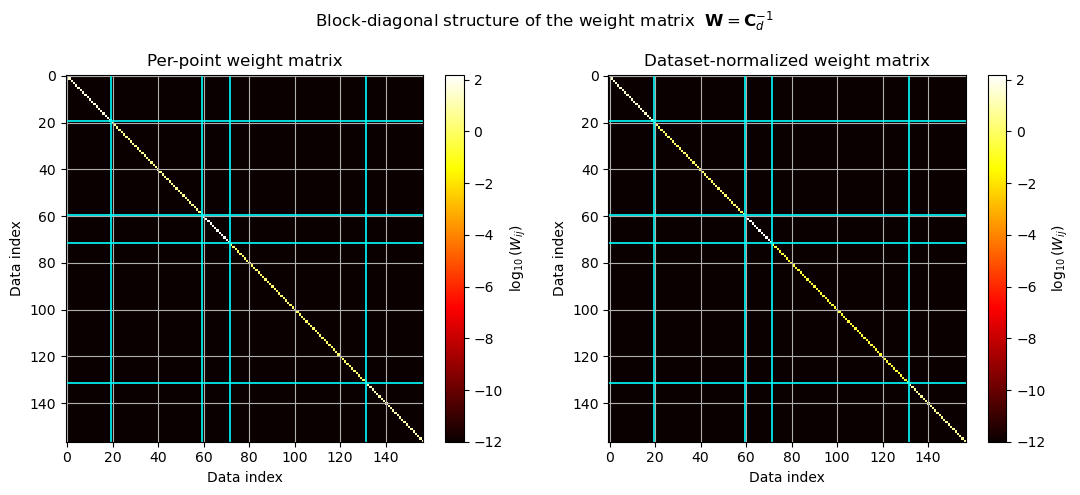

In [18]:
# ── Part D: K = 5 datasets with different N, σ, and optional scaling ──────────
K = 5
N_D     = [20, 40, 12, 60, 25]       # dataset sizes
sigma_D = [0.15, 0.5, 0.08, 0.9, 0.3]  # noise levels
x_ranges = [(0,2), (1,4), (3,5), (0,5), (2,5)]  # each covers a different x window
colors  = ['C0','C1','C2','C3','C4']

x_D = [np.linspace(a, b, n) for (a,b), n in zip(x_ranges, N_D)]
G_D = [make_G(x) for x in x_D]
d_D = [G @ m_true + rng.normal(0, s, n)
       for G, s, n in zip(G_D, sigma_D, N_D)]

# --- Option A: pure per-point weights (1/sigma_k^2 per point) ----------------
W_blocks_pp = [np.eye(n)/s**2 for n, s in zip(N_D, sigma_D)]
W_D_pp   = block_diag(*W_blocks_pp)
G_D_all  = np.vstack(G_D)
d_D_all  = np.concatenate(d_D)
m_D_pp,  Cm_D_pp  = wls(G_D_all, d_D_all, W_D_pp)

# --- Option B: dataset-normalized weights ------------------------------------
N_ref_D = min(N_D)
W_blocks_norm = [(N_ref_D/n) * np.eye(n)/s**2 for n, s in zip(N_D, sigma_D)]
W_D_norm = block_diag(*W_blocks_norm)
m_D_norm, Cm_D_norm = wls(G_D_all, d_D_all, W_D_norm)

print(f'K = {K} datasets combined')
print(f'  Dataset sizes:  {N_D}')
print(f'  Noise levels:   {sigma_D}')
print()
print(f"{'Method':30s}  {'slope':>8s}  {'±':>6s}  {'intercept':>10s}  {'±':>6s}")
print('-'*67)
print(f"{'True':30s}  {m_true[0]:8.4f}  {'---':>6s}  {m_true[1]:10.4f}  {'---':>6s}")
print(f"{'Per-point weights':30s}  {m_D_pp[0]:8.4f}  {np.sqrt(Cm_D_pp[0,0]):6.4f}  {m_D_pp[1]:10.4f}  {np.sqrt(Cm_D_pp[1,1]):6.4f}")
print(f"{'Dataset-normalized wts':30s}  {m_D_norm[0]:8.4f}  {np.sqrt(Cm_D_norm[0,0]):6.4f}  {m_D_norm[1]:10.4f}  {np.sqrt(Cm_D_norm[1,1]):6.4f}")

# ── Figure 1: data and fit ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Plot the true model and all 5 datasets on both panels
for ax in [axes[0], axes[1]]:
    ax.plot(x_plot, G_plot @ m_true, 'k--', lw=1.5, label='True model', zorder=5)
    ax.plot(x_D[0], d_D[0], '.', color=colors[0], ms=6, alpha=0.7, label=f'D1: N={N_D[0]}, σ={sigma_D[0]}')
    ax.plot(x_D[1], d_D[1], '.', color=colors[1], ms=6, alpha=0.7, label=f'D2: N={N_D[1]}, σ={sigma_D[1]}')
    ax.plot(x_D[2], d_D[2], '.', color=colors[2], ms=6, alpha=0.7, label=f'D3: N={N_D[2]}, σ={sigma_D[2]}')
    ax.plot(x_D[3], d_D[3], '.', color=colors[3], ms=6, alpha=0.7, label=f'D4: N={N_D[3]}, σ={sigma_D[3]}')
    ax.plot(x_D[4], d_D[4], '.', color=colors[4], ms=6, alpha=0.7, label=f'D5: N={N_D[4]}, σ={sigma_D[4]}')

# Per-point weights fit (left panel)
y_fit_D_pp, y_band_D_pp = prediction_band(G_plot, m_D_pp, Cm_D_pp)
axes[0].plot(x_plot, y_fit_D_pp, '-', color='k', lw=2.5, label='Combined WLS')
axes[0].fill_between(x_plot, y_fit_D_pp - y_band_D_pp, y_fit_D_pp + y_band_D_pp, color='k', alpha=0.15, label='±2σ')
axes[0].set_title('Per-point weights', fontsize=10)
axes[0].set_xlabel('x')
axes[0].legend(fontsize=8, ncol=2)

# Dataset-normalized weights fit (right panel)
y_fit_D_norm, y_band_D_norm = prediction_band(G_plot, m_D_norm, Cm_D_norm)
axes[1].plot(x_plot, y_fit_D_norm, '-', color='k', lw=2.5, label='Combined WLS')
axes[1].fill_between(x_plot, y_fit_D_norm - y_band_D_norm, y_fit_D_norm + y_band_D_norm, color='k', alpha=0.15, label='±2σ')
axes[1].set_title('Dataset-normalized weights', fontsize=10)
axes[1].set_xlabel('x')
axes[1].legend(fontsize=8, ncol=2)

axes[0].set_ylabel('y')
fig.suptitle(f'Part D: K={K} datasets — per-point vs dataset-normalized weighting', fontsize=12)
plt.tight_layout()
plt.show()

# ── Figure 2: block-diagonal weight matrix ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Compute dataset boundary positions for drawing block dividers
cumN = np.cumsum([0] + N_D)

# Per-point weight matrix (left panel)
im = axes[0].imshow(np.log10(W_D_pp + 1e-12), aspect='auto', cmap='hot', interpolation='nearest')
plt.colorbar(im, ax=axes[0], label=r'$\log_{10}(W_{ij})$')
axes[0].set_title('Per-point weight matrix')
axes[0].set_xlabel('Data index')
axes[0].set_ylabel('Data index')
axes[0].axhline(cumN[1] - 0.5, color='cyan', lw=1.2)
axes[0].axvline(cumN[1] - 0.5, color='cyan', lw=1.2)
axes[0].axhline(cumN[2] - 0.5, color='cyan', lw=1.2)
axes[0].axvline(cumN[2] - 0.5, color='cyan', lw=1.2)
axes[0].axhline(cumN[3] - 0.5, color='cyan', lw=1.2)
axes[0].axvline(cumN[3] - 0.5, color='cyan', lw=1.2)
axes[0].axhline(cumN[4] - 0.5, color='cyan', lw=1.2)
axes[0].axvline(cumN[4] - 0.5, color='cyan', lw=1.2)

# Dataset-normalized weight matrix (right panel)
im = axes[1].imshow(np.log10(W_D_norm + 1e-12), aspect='auto', cmap='hot', interpolation='nearest')
plt.colorbar(im, ax=axes[1], label=r'$\log_{10}(W_{ij})$')
axes[1].set_title('Dataset-normalized weight matrix')
axes[1].set_xlabel('Data index')
axes[1].set_ylabel('Data index')
axes[1].axhline(cumN[1] - 0.5, color='cyan', lw=1.2)
axes[1].axvline(cumN[1] - 0.5, color='cyan', lw=1.2)
axes[1].axhline(cumN[2] - 0.5, color='cyan', lw=1.2)
axes[1].axvline(cumN[2] - 0.5, color='cyan', lw=1.2)
axes[1].axhline(cumN[3] - 0.5, color='cyan', lw=1.2)
axes[1].axvline(cumN[3] - 0.5, color='cyan', lw=1.2)
axes[1].axhline(cumN[4] - 0.5, color='cyan', lw=1.2)
axes[1].axvline(cumN[4] - 0.5, color='cyan', lw=1.2)

fig.suptitle('Block-diagonal structure of the weight matrix  $\\mathbf{W} = \\mathbf{C}_d^{-1}$', fontsize=12)
plt.tight_layout()
plt.show()

### Part D take-away

The recipe for combining $K$ datasets is always the same:

1. **Stack** the design matrices and data vectors: $\mathbf{G}_\text{all}$, $\mathbf{d}_\text{all}$.
2. **Assemble** the block-diagonal $\mathbf{C}_d$ (or equivalently its inverse $\mathbf{W}$) from the individual dataset covariances.
3. **Apply** the standard WLS formula.

The choices that require scientific judgement are:
- What is $\mathbf{C}_{d,k}$ for each dataset? (noise level, correlation structure)
- Should you include dataset-level scaling factors $\alpha_k$?  If so, how are they chosen?

The second weight matrix plot shows that normalization redistributes weight among datasets — large datasets have their per-point weights reduced so that each dataset block sums to the same total weight.

---
## Exercises

1. **Part A**: Change the x-ranges of the two datasets so they cover complementary regions (e.g., D1: $[0,2]$, D2: $[3,5]$). How does this affect the combined uncertainty compared to two overlapping datasets?

2. **Part B1**: Make $\sigma_2$ progressively larger ($0.5, 1.0, 5.0, 50.0$). At what point does D2 become effectively useless?  Does proper weighting always dominate over equal weighting?

3. **Part B2**: Increase the correlation length $\ell$ from $0$ to $5$ (the full x-range). Plot the ratio of naive-to-proper uncertainty as a function of $\ell$.  What happens in the limit $\ell \to \infty$?

4. **Part C**: Remove the systematic bias from D2.  Does dataset normalization still matter, or do per-point and normalized weights give essentially the same answer?

5. **Part D**: Add a regularization term $\lambda \mathbf{I}$ to the normal equations (ridge regression).  How does this interact with the choice of dataset weights?  Which has more influence on the solution — the dataset weights or $\lambda$?

## Checkpoint questions

1. If two datasets have the same noise level $\sigma$ and the same x-values, what does the combined $\hat{\mathbf{m}}$ equal?  What changes compared to using just one dataset?

2. Dataset A has $\sigma_A = 0.1$ and dataset B has $\sigma_B = 1.0$.  What is the ratio of their per-point weights in the WLS objective?

3. Why does using $\mathbf{W} = (1/\sigma^2)\mathbf{I}$ for correlated data lead to *over-confident* (too narrow) uncertainty estimates?

4. You have $K=3$ datasets with $N_1 = 10$, $N_2 = 500$, $N_3 = 50$.  Write down the dataset-normalized weight matrix $\tilde{\mathbf{C}}_d^{-1}$ using $N_\text{ref} = N_1$.

5. Is dataset-normalized weighting always better than per-point weighting?  Describe a scenario where per-point weighting is the right choice.

## Common mistakes

- **Forgetting to invert $\mathbf{C}_d$**: The weight matrix is $\mathbf{C}_d^{-1}$, not $\mathbf{C}_d$.  High-noise data should get *small* weight ($1/\sigma^2$), not large weight ($\sigma^2$).

- **Treating correlated data as independent**: Using $\mathbf{W} = (1/\sigma^2)\mathbf{I}$ when noise is correlated gives a formally correct *point estimate* (because the WLS estimator is still unbiased) but the **uncertainty $\mathbf{C}_m$ is wrong** — it will be too small.

- **Assuming all large datasets are better**: A dataset with 10000 data points but strong correlated noise may carry less independent information than a dataset with 20 carefully chosen, independent observations.

- **Mixing up per-point and per-dataset weights**: Scaling a dataset's covariance by $N_k$ changes the relative influence of datasets — it does *not* change the noise model within a dataset.  These are separate choices.

- **Not stating your weighting choices**: When combining datasets, always document which $\mathbf{C}_{d,k}$ and scaling factors $\alpha_k$ you used, and why.  Different choices can lead to substantially different answers.

## Summary

| Scenario | Data covariance | Key insight |
|---|---|---|
| **(A)** Similar datasets, same σ | $\sigma^2 \mathbf{I}$ (scalar cancels) | Just stack; uncertainty shrinks like $1/\sqrt{K}$ |
| **(B1)** Different noise levels | $\mathrm{diag}(\sigma_1^2,\ldots)$ | Weight by $1/\sigma_k^2$; precise data dominates |
| **(B2)** Correlated noise within a dataset | Full $\mathbf{C}_{d,k}$ (off-diagonal) | Naïve $\mathbf{I}$ underestimates uncertainty |
| **(C)** Different N, possible bias | $N_k/N_\text{ref}$ scaling | Per-point = statistically optimal if data quality is equal; normalize to give equal voice to each type |
| **(D)** K datasets | Block-diagonal $\mathbf{C}_d$ | One formula handles all cases; scientific judgement lives in the $\mathbf{C}_{d,k}$ and scaling choices |

The central message: **the data covariance matrix $\mathbf{C}_d$ encodes everything you know (or assume) about data quality**.  Getting it right is just as important as getting the forward model $\mathbf{G}$ right.